In [2]:
import os
import sys
import datetime as dt
import cmocean as cmo

import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

# import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import haversine, hp_mods, get_nn_lon_lat_index

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/franmorr/.conda/envs/hk26_env/share/proj failed


In [3]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=4, time='PT1H').to_dask().pipe(hp_mods)

## Onset Period analysis

Marcia's technique takes the following steps:
1. Butterworth filter precipitation timeseries with a 60-day window Pr_{60}
2. Take time derivative of Pr_{60}
3. Identify periods where Pr_{60} and dPr_{60}/dt are positive for 30 days or more.
4. Optionally, take each standard season and apply the RefineOns method to check it looks sensible.

Here we also calculate seasonality to check whether this is a meaningfully seasonal cycle as in [Kahana et al. (2024)](https://www.frontiersin.org/journals/climate/articles/10.3389/fclim.2024.1419704/full).

In [4]:
import OnsetPeriod_toolbox as optb

def onset_period(
    pp,
    deltat=None,
    max_dry_frac_rainfall=0.3,
    refine=False,
    precip_threshold=None,
    intensity_threshold=None,
):
    if deltat == None:
        deltat = pp.time.dt.dayofyear[0].item()
    # step 1
    flt = optb.butterworth(pp, fwin)

    # step 2
    grd = np.gradient(flt)

    # step 3
    rny = xr.where(((flt > 0) & (grd > 0)), 1, 0)
    fd, lns = optb.FindOnsetPeriods(rny, minlen)

    #### NOT SURE WHETHER TO REMOVE P1
    # remove first onset period if it starts at the very beginning of the sim
    if fd and fd[0] == 0:
        fd = fd[1:]
        lns = lns[1:]

    if refine:
        for ons_ix in range(len(fd)):
            this_pp = pp[fd[ons_ix] : fd[ons_ix] + lns[ons_ix]]
            fd[ons_ix], lns[ons_ix] = optb.RefineOns(
                pp, pp.mean(dim="time") * max_dry_frac_rainfall
            )

    if precip_threshold:
        if pp.mean(dim="time") < precip_threshold:
            return np.array([np.nan]), np.array([np.nan])

    if intensity_threshold:
        ons_ix=0
        while ons_ix in range(len(fd)):
            this_grd_mean = (grd[fd[ons_ix] : fd[ons_ix] + lns[ons_ix]]).mean()
            if this_grd_mean < intensity_threshold:
                fd.remove(fd[ons_ix])
                lns.remove(lns[ons_ix])
            else:
                ons_ix+=1

    # shift back to day of year rather than day of simulation
    first_days = np.array(fd) + deltat
    last_days = np.array(fd) + np.array(lns) + deltat

    return first_days, last_days

def onset_period_1d(
    pp_1d,
    time,
    max_periods=5,
    max_dry_frac_rainfall=0.3,
    refine=False,
    precip_threshold=None,
    intensity_threshold=None,
):
    """
    Apply onset_period to one grid-cell time series.

    Returns fixed-length arrays so xarray can combine outputs.
    """
    pp = xr.DataArray(
        pp_1d,
        dims=["time"],
        coords={"time": time},
    )

    deltat = int(pp.time.dt.dayofyear[0].item())

    first_days, last_days = onset_period(
        pp,
        deltat=deltat,
        max_dry_frac_rainfall=max_dry_frac_rainfall,
        refine=refine,
        precip_threshold=precip_threshold,
        intensity_threshold=intensity_threshold,
    )

    first_out = np.full(max_periods, np.nan)
    last_out = np.full(max_periods, np.nan)

    n = min(len(first_days), max_periods)
    first_out[:n] = first_days[:n]
    last_out[:n] = last_days[:n]

    return first_out, last_out

In [5]:
np.array(range(10,100,2))

array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42,
       44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76,
       78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98])

In [6]:
for cell_ix in range(len(ds.pr.cell)):
    if cell_ix%100==0:
        print(cell_ix,(ds.sel(cell=cell_ix).lon.values,ds.sel(cell=cell_ix).lat.values))

0 (array(45.), array(2.38801546))
100 (array(61.875), array(38.68218745))
200 (array(38.07692308), array(51.25580695))
300 (array(123.75), array(22.02431284))
400 (array(123.75), array(32.7971683))
500 (array(153.), array(75.34073424))
600 (array(253.125), array(38.68218745))
700 (array(192.27272727), array(57.39952354))
800 (array(303.75), array(12.02469918))
900 (array(298.125), array(27.27961274))
1000 (array(285.), array(63.44828368))
1100 (array(22.5), array(-7.18075578))
1200 (array(337.5), array(2.38801546))
1300 (array(106.875), array(-22.02431284))
1400 (array(106.875), array(7.18075578))
1500 (array(101.25), array(22.02431284))
1600 (array(202.5), array(-16.9577633))
1700 (array(151.875), array(-2.38801546))
1800 (array(264.375), array(-32.7971683))
1900 (array(281.25), array(2.38801546))
2000 (array(281.25), array(12.02469918))
2100 (array(53.18181818), array(-57.39952354))
2200 (array(27.), array(-44.99388015))
2300 (array(45.), array(-7.18075578))
2400 (array(148.84615385)

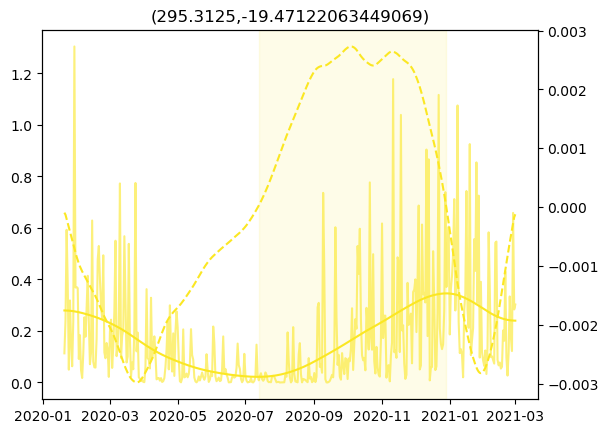

In [41]:
fwin=60
minlen=30
for cell_ix in [3050]:
    color=plt.cm.viridis(cell_ix/len(ds.pr.cell))
    pp = ds.pr.isel(cell=cell_ix).resample(time="1D").mean()*3600
    
    flt = optb.butterworth(pp, fwin)
    grd = np.gradient(flt)
    fds, lds = onset_period_1d(pp,pp.time,refine=False,intensity_threshold=pp.mean()/100)
    fds, lds = onset_period_1d(pp,pp.time,refine=False,intensity_threshold=None)
    # fds, lds = onset_period_1d(pp,pp.time,refine=False,precip_threshold=None,intensity_threshold=pp.mean()/100/3600)

    fig, ax = plt.subplots()
    
    ax.plot(pp.time, pp, color=color,alpha=0.6)
    [
        ax.axvspan(
            dt.datetime(2020,1,1)+dt.timedelta(days=int(fds[ix])-1),
            dt.datetime(2020,1,1)+dt.timedelta(days=int(lds[ix])-1),
            alpha=0.1,
            color=color,
        ) 
        for ix in range(len(fds)) if int(fds[ix]==fds[ix])
    ]
    ax.plot(pp.time,flt,color=color,)
    ax.set_title(f"({pp.lon.data},{pp.lat.data})")

    ax2 = ax.twinx()
    
    ax2.plot(pp.time,grd,"--",color=color)

In [ ]:
def constrain_healpix(ds, left, right, bottom, top):
    region_mask = (
        (ds.lon > left) & (ds.lon < right) & (ds.lat > bottom) & (ds.lat < top)
    )
    return ds.where(region_mask)

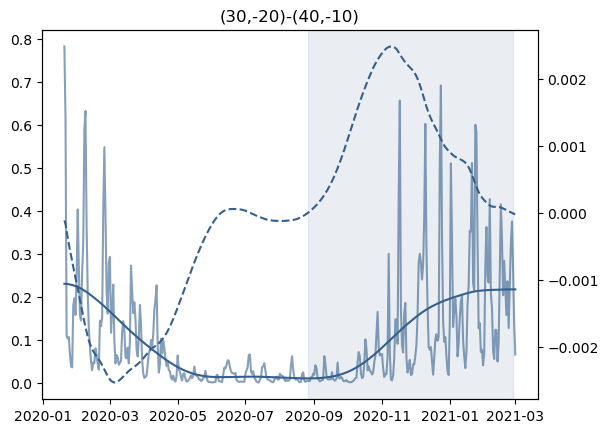

In [72]:
    fwin=60
    minlen=30
    left=30
    right=40
    bottom=-20
    top=-10

    color=plt.cm.viridis(0.3)
    pp = (constrain_healpix(ds,left,right,bottom,top).pr.resample(time="1D").mean()*3600).mean(dim="cell")
    
    flt = optb.butterworth(pp, fwin)
    grd = np.gradient(flt)
    fds, lds = onset_period_1d(pp,pp.time,refine=False,intensity_threshold=pp.mean()/100)
    # fds, lds = onset_period_1d(pp,pp.time,refine=False,intensity_threshold=None)
    # fds, lds = onset_period_1d(pp,pp.time,refine=False,precip_threshold=None,intensity_threshold=pp.mean()/100/3600)

    fig, ax = plt.subplots()
    
    ax.plot(pp.time, pp, color=color,alpha=0.6)
    [
        ax.axvspan(
            dt.datetime(2020,1,1)+dt.timedelta(days=int(fds[ix])-1),
            dt.datetime(2020,1,1)+dt.timedelta(days=int(lds[ix])-1),
            alpha=0.1,
            color=color,
        ) 
        for ix in range(len(fds)) if int(fds[ix]==fds[ix])
    ]
    ax.plot(pp.time,flt,color=color,)
    ax.set_title(f"({left},{bottom})-({right},{top})")

    ax2 = ax.twinx()
    
    ax2.plot(pp.time,grd,"--",color=color)

# Plot maps of onset data

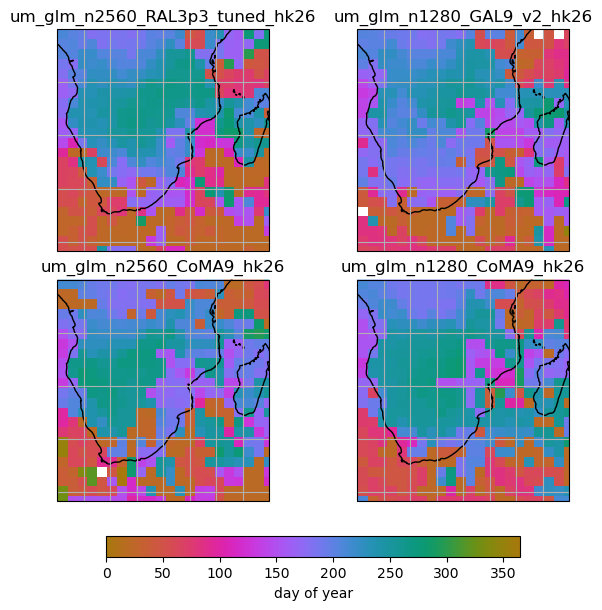

In [68]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=(6,6),
    subplot_kw={"projection": projection},
    layout="constrained",
)

zoom=5
def plot_ax(ax,sim,extent=None):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()
    da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_{zoom}_first_days.nc"
        ).sel(period=0)
    m=da.plot(cmap=cmo.cm.phase,vmin=0,vmax=365, ax=ax,add_colorbar=False)
    ax.set_title(sim)
    ax.coastlines()
    ax.gridlines()
    return ax,m

left=10
right=50
bottom=-40
top=-0
ax,m=plot_ax(axes[0,0],"um_glm_n2560_RAL3p3_tuned_hk26",[left,right,bottom,top])
ax,m=plot_ax(axes[0,1],"um_glm_n1280_GAL9_v2_hk26",[left,right,bottom,top])
ax,m=plot_ax(axes[1,0],"um_glm_n2560_CoMA9_hk26",[left,right,bottom,top])
ax,m=plot_ax(axes[1,1],"um_glm_n1280_CoMA9_hk26",[left,right,bottom,top])

fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="day of year",
)

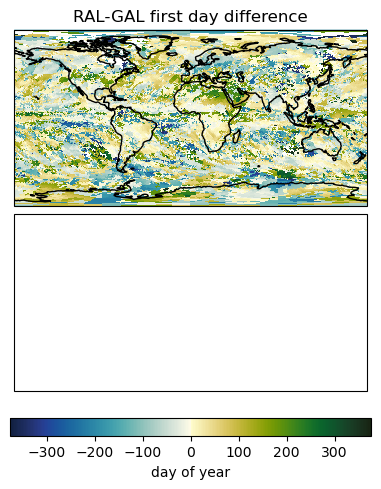

In [24]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    1,
    # height_ratios=[1] * len(zooms) + [0.1],
    # figsize=(6, 10),
    subplot_kw={"projection": projection},
    layout="constrained",
)
sim="um_glm_n2560_RAL3p3_tuned"
axes[0].coastlines()
axes[0].set_global()
ral_da = xr.open_dataarray(
    f"onset_dates/{sim}_hk26_zoom_6_first_days.nc"
).sel(period=0)

sim="um_glm_n1280_GAL9_v2_hk26"
gal_da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
diff_da=ral_da-gal_da
m=diff_da.plot(cmap=cmo.cm.delta, ax=axes[0],add_colorbar=False)
# axes.set_title(sim)

# im=egh.healpix_show(da,cmap=cmo.cm.phase)
# plt.colorbar(im)
axes[0].set_title("RAL-GAL first day difference")
fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="day of year",
)

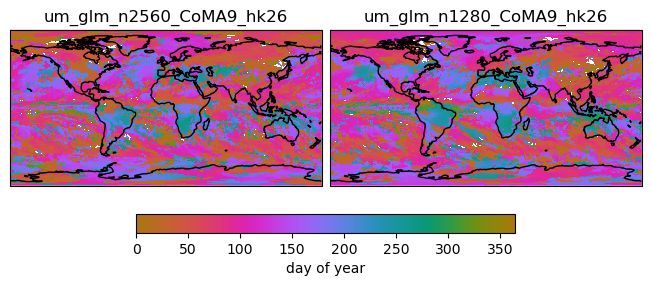

In [5]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    # figsize=(6, 10),
    subplot_kw={"projection": projection},
    layout="constrained",
)
sim="um_glm_n2560_CoMA9_hk26"
axes[0].coastlines()
axes[0].set_global()
da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
m=da.plot(cmap=cmo.cm.phase,vmin=0,vmax=365, ax=axes[0],add_colorbar=False)
axes[0].set_title(sim)

sim="um_glm_n1280_CoMA9_hk26"
axes[1].coastlines()
axes[1].set_global()
da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
m=da.plot(cmap=cmo.cm.phase,vmin=0,vmax=365, ax=axes[1],add_colorbar=False)
axes[1].set_title(sim)

# im=egh.healpix_show(da,cmap=cmo.cm.phase)
# plt.colorbar(im)

fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="day of year",
)

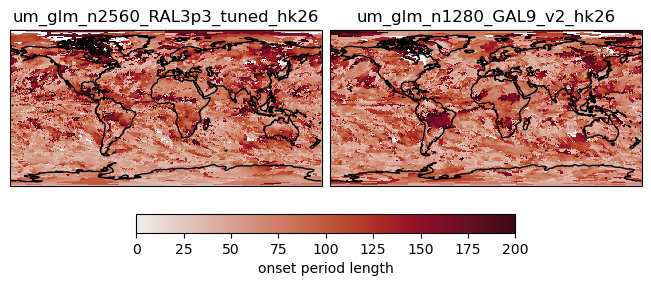

In [8]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    # figsize=(6, 10),
    subplot_kw={"projection": projection},
    layout="constrained",
)
sim="um_glm_n2560_RAL3p3_tuned_hk26"
axes[0].coastlines()
axes[0].set_global()
da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_last_days.nc"
).sel(period=0)-xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
m=da.plot(cmap=cmo.cm.amp,vmin=0,vmax=200, ax=axes[0],add_colorbar=False)
axes[0].set_title(sim)

sim="um_glm_n1280_GAL9_v2_hk26"
axes[1].coastlines()
axes[1].set_global()
da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_last_days.nc"
).sel(period=0)-xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
m=da.plot(cmap=cmo.cm.amp,vmin=0,vmax=200, ax=axes[1],add_colorbar=False)
axes[1].set_title(sim)

# im=egh.healpix_show(da,cmap=cmo.cm.phase)
# plt.colorbar(im)

fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="onset period length",
)
# fig.suptitle("length of onset")

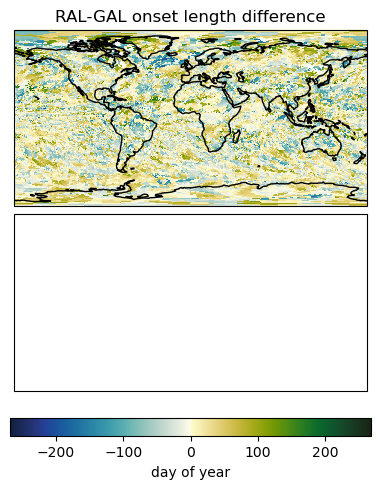

In [7]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    1,
    # height_ratios=[1] * len(zooms) + [0.1],
    # figsize=(6, 10),
    subplot_kw={"projection": projection},
    layout="constrained",
)
sim="um_glm_n2560_RAL3p3_tuned"
axes[0].coastlines()
axes[0].set_global()
ral_da = xr.open_dataarray(
    f"onset_dates/{sim}_hk26_zoom_6_last_days.nc"
).sel(period=0)-xr.open_dataarray(
    f"onset_dates/{sim}_hk26_zoom_6_first_days.nc"
).sel(period=0)

sim="um_glm_n1280_GAL9_v2_hk26"
gal_da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_last_days.nc"
).sel(period=0)-xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
diff_da=ral_da-gal_da
m=diff_da.plot(cmap=cmo.cm.delta, ax=axes[0],add_colorbar=False)
# axes.set_title(sim)

# im=egh.healpix_show(da,cmap=cmo.cm.phase)
# plt.colorbar(im)
axes[0].set_title("RAL-GAL onset length difference")
fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="day of year",
)

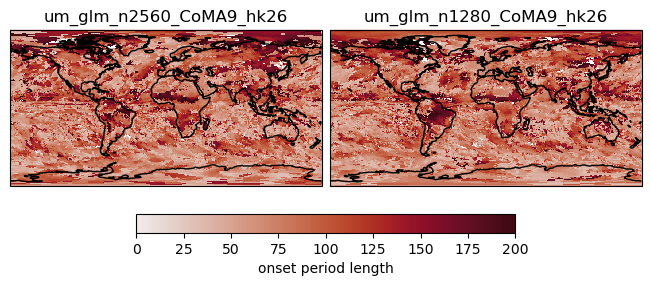

In [9]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    # figsize=(6, 10),
    subplot_kw={"projection": projection},
    layout="constrained",
)
sim="um_glm_n2560_CoMA9_hk26"
axes[0].coastlines()
axes[0].set_global()
da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_last_days.nc"
).sel(period=0)-xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
m=da.plot(cmap=cmo.cm.amp,vmin=0,vmax=200, ax=axes[0],add_colorbar=False)
axes[0].set_title(sim)

sim="um_glm_n1280_CoMA9_hk26"
axes[1].coastlines()
axes[1].set_global()
da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_last_days.nc"
).sel(period=0)-xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
m=da.plot(cmap=cmo.cm.amp,vmin=0,vmax=200, ax=axes[1],add_colorbar=False)
axes[1].set_title(sim)

# im=egh.healpix_show(da,cmap=cmo.cm.phase)
# plt.colorbar(im)

fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="onset period length",
)
# fig.suptitle("length of onset")

In [30]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    # figsize=(6, 10),
    subplot_kw={"projection": projection},
    layout="constrained",
)
sim="um_glm_n2560_RAL3p3_tuned"
axes[0].coastlines()
axes[0].set_global()
da = xr.open_dataarray(
    f"onset_dates/{sim}_hk26_zoom_6_first_days.nc"
).sel(period=0)
m=da.plot(cmap=cmo.cm.phase,vmin=0,vmax=365, ax=axes[0],add_colorbar=False)
axes[0].set_title(sim)

sim="um_glm_n1280_GAL9_v2_hk26"
axes[1].coastlines()
axes[1].set_global()
da = xr.open_dataarray(
    f"onset_dates/{sim}_zoom_6_first_days.nc"
).sel(period=0)
m=da.plot(cmap=cmo.cm.phase,vmin=0,vmax=365, ax=axes[1],add_colorbar=False)
axes[1].set_title(sim)

# im=egh.healpix_show(da,cmap=cmo.cm.phase)
# plt.colorbar(im)

fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="day of year",
)

/home/users/franmorr/hk26/hackathon-monsoons/onset_identification/onset_dates/um_glm_n2560_RAL3p3_tuned_hk26_zoom_6_first_days.nc


In [ ]:
/home/users/franmorr/hk26/hackathon-monsoons/onset_identification/onset_dates/um_glm_n2560_RAL3p3_tuned_zoom_6_first_days.nc
/home/users/franmorr/hk26/hackathon-monsoons/onset_identification/onset_dates/um_glm_n2560_RAL3p3_tuned_hk26_zoom_6_first_days.nc
